In [1]:
import pandas as pd
import joblib

rfm = pd.read_csv("../data/rfm_churn.csv")
rf = joblib.load("../src/churn_model.pkl")

rfm.head()

,customer_unique_id,recency,frequency,monetary,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,0
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,1


In [2]:
X_all = rfm[["frequency", "monetary"]]

rfm["churn_probability"] = rf.predict_proba(X_all)[:, 1]
rfm[["customer_unique_id", "frequency", "monetary", "churn_probability"]].head()

,customer_unique_id,frequency,monetary,churn_probability
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,0.488787
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,0.514851
2,0000f46a3911fa3c0805444483337064,1,69.00,0.489982
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,0.511133
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,0.494818


In [7]:
rfm["risk_tier"] = pd.qcut(
    rfm["churn_probability"],
    q=[0, 0.33, 0.66, 1.0],
    labels=["Low", "Medium", "High"]
)

rfm["risk_tier"].value_counts()

risk_tier
High      31504
Low       31474
Medium    30380
Name: count, dtype: int64

In [8]:
revenue_by_tier = rfm.groupby("risk_tier")["monetary"].sum()
total_revenue = rfm["monetary"].sum()

print(revenue_by_tier)
print("\nTotal revenue:", round(total_revenue, 2))
print("\n% of revenue at High risk:", round(revenue_by_tier["High"] / total_revenue * 100, 1), "%")

risk_tier
Low       4844511.49
Medium    6637310.62
High      1739676.00
Name: monetary, dtype: float64

Total revenue: 13221498.11

% of revenue at High risk: 13.2 %


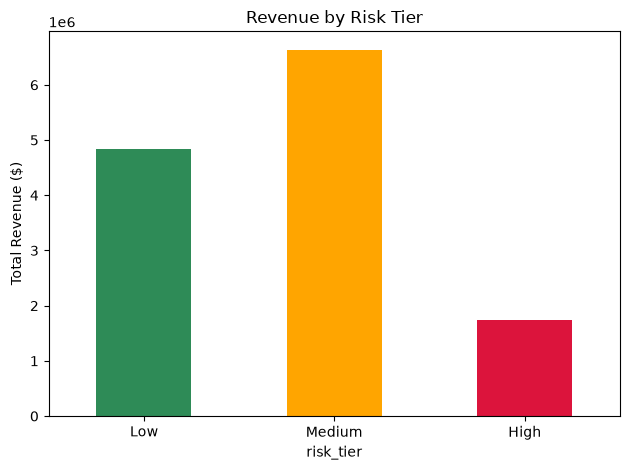

In [9]:
import matplotlib.pyplot as plt

revenue_by_tier.plot(kind="bar", color=["seagreen", "orange", "crimson"])
plt.title("Revenue by Risk Tier")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../dashboard/revenue_at_risk.png", dpi=150)
plt.show()

In [10]:
rfm.to_csv("../data/customer_risk_scores.csv", index=False)
print("Saved customer_risk_scores.csv")

Saved customer_risk_scores.csv


## Day 7 Notes — Revenue at Risk
- Initial fixed-threshold tiers (0.33/0.66 cutoffs) put 99.9% of customers in "Medium" —
  because churn probabilities were tightly clustered (0.49-0.51), reflecting the weak
  RFM signal identified on Day 6.
- Switched to quantile-based tiers (pd.qcut) to rank customers by RELATIVE risk instead
  of absolute probability — gives a usable, evenly distributed split (~31K per tier).
- Total revenue: $13,221,498.11
- Revenue at High risk tier: $1,739,676.00 (13.2% of total)